In [21]:
import tensorflow as tf
import os
import numpy as np
from sklearn.model_selection import train_test_split
from siamese_layer import SiameseLayer
import keras
from model_training import Model_Training
from keras.models import Model
from keras.layers import Input, Dense
from data_preprocessing import make_siamese_model
from sklearn.metrics import classification_report
import cv2
import matplotlib.pyplot as plt


In [ ]:
model_path = os.path.join('checkpoints', 'model', 'modelV8.keras')

# def make_siamese_model():
#         embeddings = Model_Training().embedding()
#         embeddings.summary()
#         input_image = Input(name= 'Input_img', shape=(100, 100, 3))
#         validation_image = Input(name= 'validation_img', shape=(100, 100, 3))
#         inp_embedding = embeddings(input_image)
#         val_embedding = embeddings(validation_image)
        
#         siamese_layer = SiameseLayer()
#         siamese_layer._name = "distance"
#         distances = siamese_layer(inp_embedding,val_embedding)
        
#         classifier = Dense(1,activation="sigmoid")(distances)
        
#         return Model(inputs=[input_image, validation_image], outputs=classifier, name= 'Siamese_Models')
    
    
model = keras.models.load_model(model_path, custom_objects={'SiameseLayer':SiameseLayer})

Neg_path = os.path.join("data", "Neg_img")
Anch_path = os.path.join("data", "Anchor_img")
Pos_path = os.path.join("data", "Pos_img")


In [23]:
for inp in model.inputs:
    print(inp.name, inp.shape)

Input_img (None, 100, 100, 3)
validation_img (None, 100, 100, 3)


In [24]:
Neg = tf.data.Dataset.list_files(os.path.join(Neg_path, "*.jpg")).take(3000)
Anchor = tf.data.Dataset.list_files(os.path.join(Anch_path, "*.jpg")).take(3000)
Pos = tf.data.Dataset.list_files(os.path.join(Pos_path, "*.jpg")).take(3000)

In [25]:
Positives = tf.data.Dataset.zip((Anchor, Pos, tf.data.Dataset.from_tensor_slices(tf.ones(len(Anchor)))))
Negatives = tf.data.Dataset.zip((Anchor, Neg, tf.data.Dataset.from_tensor_slices(tf.zeros(len(Anchor)))))

data = Positives.concatenate(Negatives)

In [26]:
def preprocess(filepath):
    byte_img = tf.io.read_file(filepath)
    img = tf.io.decode_jpeg(byte_img)
    img = tf.image.resize(img, (100, 100))
    img = img /255.0
    return img

# def preprocess_twin(input_image, validation_image, label):
#     return (preprocess(input_image), preprocess(validation_image), label) 
def preprocess_twin(input_image, validation_image, label):
    return {
        "Input_img": preprocess(input_image),
        "validation_img": preprocess(validation_image)
    }, label

def map_data2(Data):
    Data = Data.map(preprocess_twin).cache()
    Data = Data.shuffle(buffer_size=10000000, seed=42)
    total_size = round(len(Data))
    train_size = round(total_size * 0.7)
    test_valid_size = total_size - train_size
    test_size = round(test_valid_size * 0.5)
    
    train_data = Data.take(train_size)
    test_valid_data = Data.skip(train_size)
    test_data = test_valid_data.take(test_size)
    valid_data = test_valid_data.skip(test_size)
    
    train_data = train_data.batch(16).prefetch(tf.data.AUTOTUNE)
    
    valid_data = valid_data.batch(16).prefetch(tf.data.AUTOTUNE)
    
    test_data = test_data.batch(16).prefetch(tf.data.AUTOTUNE)
    
    return train_data, test_data, valid_data

In [27]:
train_data, test_data, valid_data = map_data2(data)

model2 = make_siamese_model()

Model: "embedding"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input Layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 91, 91, 64)     │        19,264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 40, 40, 128)    │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 17, 17, 128)    │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 6, 6, 256)      │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4096)           │    37,752,832 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,960,448 (148.62 MB)

 Trainable params: 38,960,448 (148.62 MB)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step


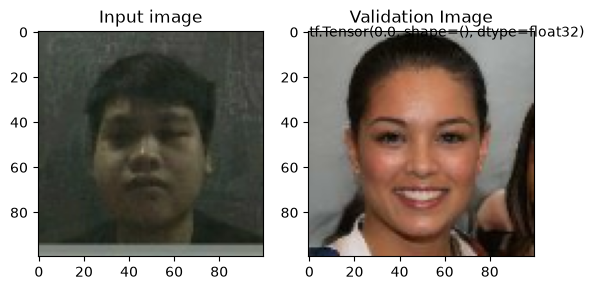

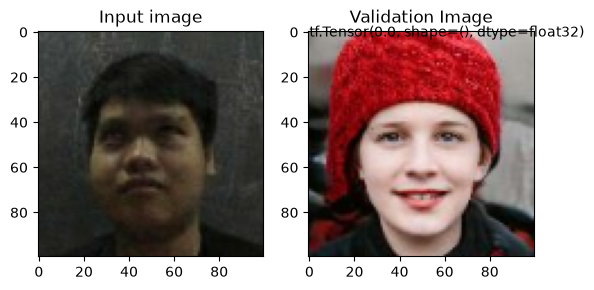

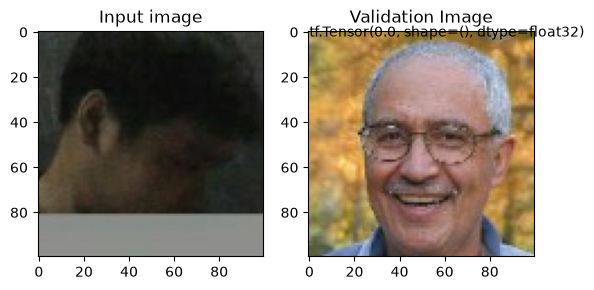

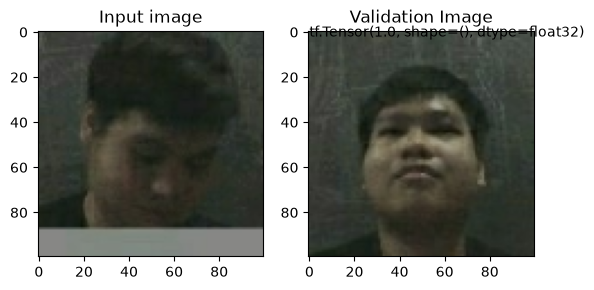

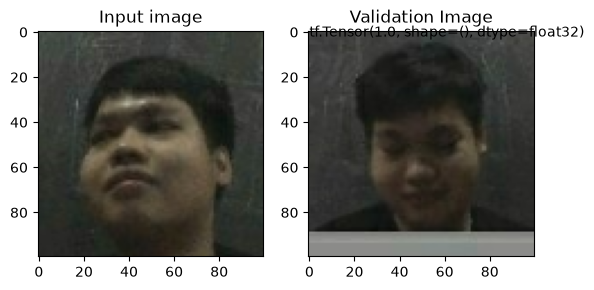

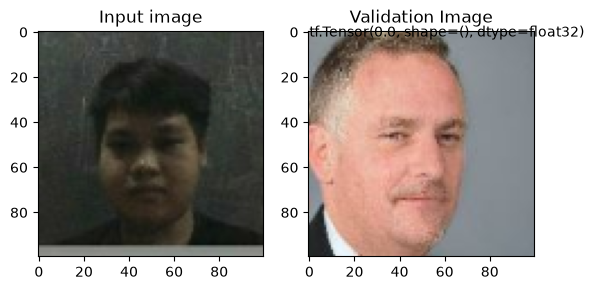

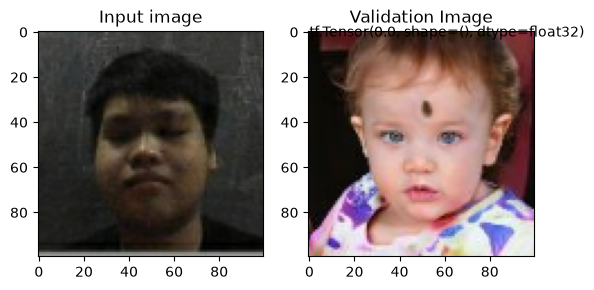

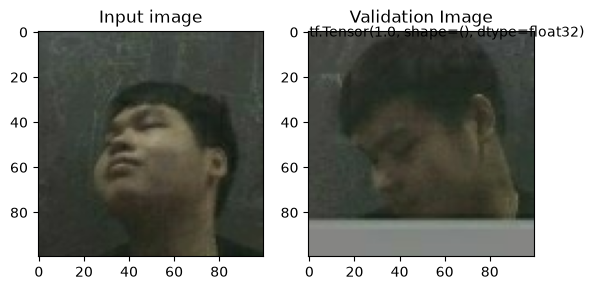

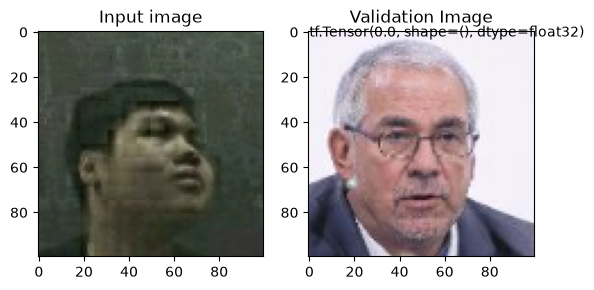

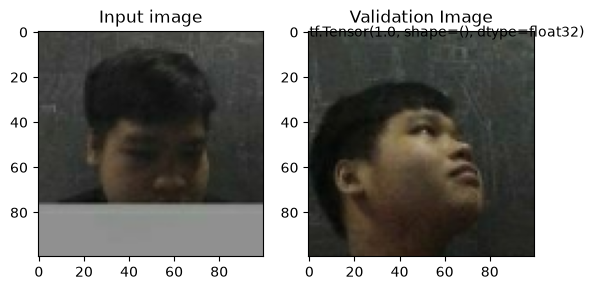

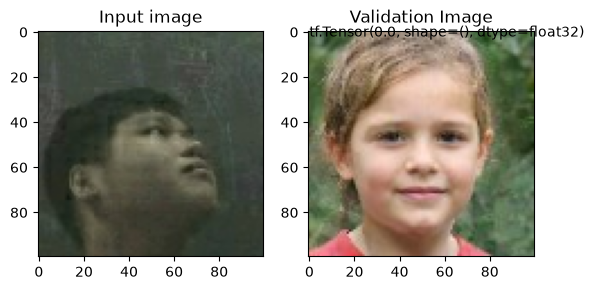

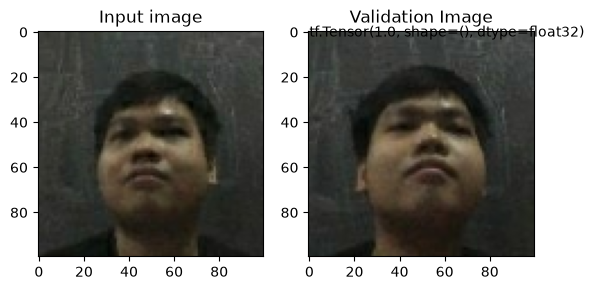

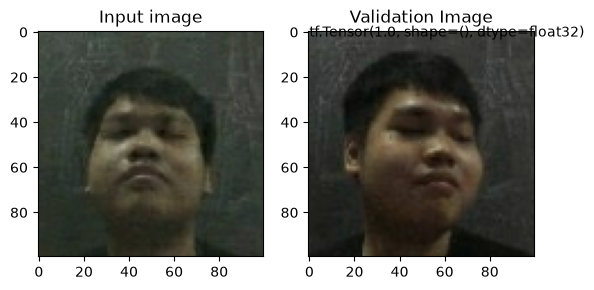

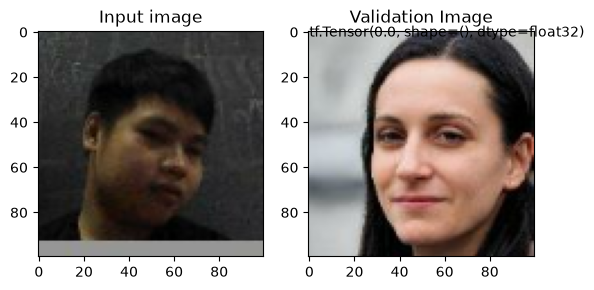

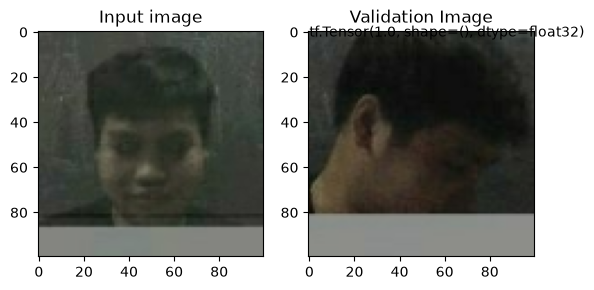

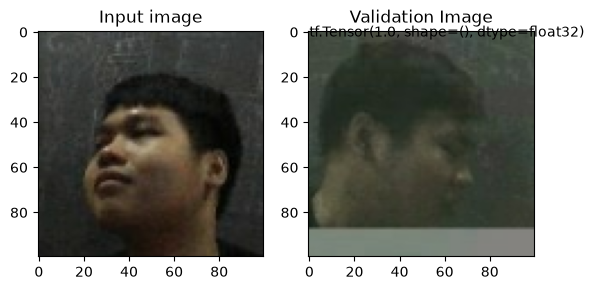

tf.Tensor([0. 0. 0. 1. 1. 0. 0. 1. 0. 1. 0. 1. 1. 0. 1. 1.], shape=(16,), dtype=float32)
Predictions is [array([[8.2259105e-10],
       [2.5873253e-05],
       [2.0950579e-13],
       [9.9999982e-01],
       [1.0000000e+00],
       [2.4571343e-09],
       [7.6327723e-07],
       [9.9998522e-01],
       [1.2711230e-07],
       [9.9998915e-01],
       [6.4040884e-09],
       [9.5069236e-01],
       [9.9902344e-01],
       [7.2992474e-09],
       [9.9965757e-01],
       [1.0000000e+00]], dtype=float32)]


In [32]:
for input_img, label in test_data.take(1):
    predicted = []
    predictions = model.predict(input_img)
    predicted.append(predictions)
    for i, (input_image, validation_image) in enumerate(zip(input_img['Input_img'], input_img['validation_img'])):
        plt.subplot(1,2,1)
        plt.imshow(input_image)
        plt.title('Input image')
        
        plt.subplot(1,2,2)
        plt.imshow(validation_image)
        plt.title('Validation Image')
        
        plt.text(0,2,  str(label[i]))
        plt.show()
    print(label)
    print(f"Predictions is {predicted}")

In [33]:
input_img_batch = input_img["Input_img"]
valid_img_batch = input_img["validation_img"]
Predictions = model.predict({
    "Input_img": input_img_batch,
    "validation_img": valid_img_batch
})
print([1 if prediction > 0.5 else 0 for prediction in Predictions ])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
[0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1]


In [30]:
y_pred = (Predictions.ravel()>0.5).astype(int)
y_true = label.numpy().astype(int) if hasattr(label, "numpy") else np.array(label).astype(int)

results = classification_report(y_true, y_pred)
print(results)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         7
           1       1.00      1.00      1.00         9

    accuracy                           1.00        16
   macro avg       1.00      1.00      1.00        16
weighted avg       1.00      1.00      1.00        16

